# Multi-Task v3 — Minimal: Seg + Cobb_Direct

Surgical regression to v1's winning architecture, applying v2's lessons.

## What v2 told us

| Head | v1 result | v2 result | v3 decision |
|---|---|---|---|
| **seg** | dice 0.684 | dice 0.528 (eaten by sev_head gradients) | **keep** |
| **cobb_direct** | MAE 9.34°, r=0.838 | MAE 12.65°, r=0.659 (noisy under Kendall blowup) | **keep** |
| kpt heatmap | MAE 19.69°, r=0.24 | MAE 25.15°, r=**−0.21** (inverted under 6× weight) | **drop** — structurally dead |
| sev (4-way softmax) | not present | mode collapse: only `severe`/`moderate` predicted | **drop** — derive severity from cobb_direct bucket (v1 acc 0.844) |
| Kendall loss | not present | over-amplified tiny-magnitude tasks (kpt weight → 6×, cobb → 5.6×) | **keep with `log_var ≥ −1.5` clamp** (max weight ≈ 2.24) |
| Cobb-preserving aug | not present | neutral / mildly positive | **keep** |

## v3 = v1 minus dead heads, plus clamped Kendall + cobb-aware aug

Two heads, one encoder. Should:
1. Recover or beat v1 dice (less head competition for bottleneck features)
2. Match or beat v1 `cobb_direct` MAE 9.34° (same supervision, less interference)
3. Give severity for free via `cobb_direct → bucket` (v1 baseline: 0.844)

## 0 · Setup

In [2]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset
from torchvision import models

warnings.filterwarnings("ignore", message=".*lerp.*")

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [3]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.dataset import IMG_H, IMG_W, TARGET_IDS_V2, preprocess_case
from ai.training.augmentation import (
    affine_transform, intensity_jitter, horizontal_flip, elastic_deform,
    gamma_correction, gaussian_blur, clahe_like, gaussian_noise, coarse_dropout,
)
from ai.training.losses import seg_loss_fn

print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}")

size=512x256  seg_classes=18


In [4]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df, val_frac=0.2, seed=SEED):
    sh = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(sh) * val_frac)))
    return sh.iloc[n_val:].reset_index(drop=True), sh.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = pd.read_csv(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2)
n_with_cobb = TRAINABLE["cobb_angle_deg"].notna().sum()
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)} (cobb_gt={n_with_cobb})  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249 (cobb_gt=178)  train=199  val=50


## 1 · Severity Buckets (inference-only, derived from `cobb_direct`)

In [5]:
SEVERITY_BUCKETS = (("normal", 0.0, 10.0), ("mild", 10.0, 25.0),
                    ("moderate", 25.0, 40.0), ("severe", 40.0, 999.0))
SEVERITY_LABELS = [n for n, _, _ in SEVERITY_BUCKETS]

def severity_name(angle: float) -> str:
    for name, lo, hi in SEVERITY_BUCKETS:
        if lo <= angle < hi: return name
    return "unknown"

## 2 · Cobb-Preserving Augmentation (kept from v2)

Cobb magnitude is invariant under affine + flip + intensity. Only elastic warp invalidates it. Returns `(image, seg, cobb_preserved)`.

In [6]:
def augment_v5_cobb_aware(image, seg):
    cobb_preserved = True
    if torch.rand(1).item() < 0.7:
        image, seg = affine_transform(image, seg, angle_range=(-15.0, 15.0), translate_frac=0.10, scale_range=(0.85, 1.15))
    if torch.rand(1).item() < 0.5:
        image, seg = horizontal_flip(image, seg)
    if torch.rand(1).item() < 0.4:
        image, seg = elastic_deform(image, seg, alpha=40.0, sigma=6.0)
        cobb_preserved = False
    if torch.rand(1).item() < 0.5:
        image = intensity_jitter(image, gain_range=(0.7, 1.3), bias_range=(-0.15, 0.15))
    if torch.rand(1).item() < 0.3: image = gamma_correction(image)
    if torch.rand(1).item() < 0.3: image = gaussian_blur(image)
    if torch.rand(1).item() < 0.2: image = clahe_like(image)
    if torch.rand(1).item() < 0.3: image = gaussian_noise(image, std_range=(0.0, 0.08))
    if torch.rand(1).item() < 0.25: image = coarse_dropout(image, n_patches=12, patch_size=40)
    return image, seg, cobb_preserved

## 3 · Dataset — Two Targets per Sample

Returns `image`, `seg`, `cobb` scalar, `cobb_valid` flag. No keypoint heatmap, no severity label.

In [7]:
class SegCobbDataset(Dataset):
    def __init__(self, df, augment=False, target_ids=TARGET_IDS_V2):
        self.df = df.reset_index(drop=True); self.augment = augment; self.target_ids = target_ids
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        case = preprocess_case(row, target_ids=self.target_ids)
        image, seg = case["image"], case["seg"]
        cobb_preserved = True
        if self.augment:
            image, seg, cobb_preserved = augment_v5_cobb_aware(image, seg)
        gt = row.get("cobb_angle_deg")
        has_gt = pd.notna(gt) and cobb_preserved
        cobb_t = torch.tensor(float(gt) if has_gt else 0.0, dtype=torch.float32)
        valid_flag = torch.tensor(has_gt)
        return {"image": image, "seg": seg, "cobb": cobb_t, "cobb_valid": valid_flag}

def seg_cobb_collate(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}

_b = seg_cobb_collate([SegCobbDataset(TRAIN_DF.head(4), augment=True)[i] for i in range(4)])
for k, v in _b.items():
    print(f"  {k:11s}  {tuple(v.shape)}  {v.dtype}")

  image        (4, 1, 512, 256)  torch.float32
  seg          (4, 512, 256)  torch.int64
  cobb         (4,)  torch.float32
  cobb_valid   (4,)  torch.bool


## 4 · Architecture — `SegCobbEncoderUNet`

Two heads, one encoder. Identical backbone/decoder to [[EncoderUNet]]. The kpt and sev heads from v2 are removed entirely.

In [8]:
def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
    )

class _Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        dy, dx = skip.shape[2] - x.shape[2], skip.shape[3] - x.shape[3]
        if dy or dx:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x, skip], dim=1))


class SegCobbEncoderUNet(nn.Module):
    def __init__(self, in_ch=1, num_seg_classes=NUM_SEG_CLASSES, pretrained=True, dropout=0.2, cobb_norm=90.0):
        super().__init__()
        self.cobb_norm = cobb_norm
        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        b = models.resnet34(weights=weights)
        original_conv1 = b.conv1
        self.conv1 = nn.Conv2d(in_ch, 64, 7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)
        elif pretrained and in_ch == 3:
            self.conv1.weight.data = original_conv1.weight.data
        self.bn1, self.relu, self.maxpool = b.bn1, b.relu, b.maxpool
        self.layer1, self.layer2, self.layer3, self.layer4 = b.layer1, b.layer2, b.layer3, b.layer4
        self.up1 = _Up(512, 256, 256)
        self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64)
        self.up4 = _Up(64, 64, 64)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)
        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
        self._encoder_modules = [self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4]
        self._decoder_modules = [self.up1, self.up2, self.up3, self.up4, self.final_up, self.drop, self.seg_head, self.cobb_head]
    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        s1 = self.layer1(self.maxpool(x0))
        s2 = self.layer2(s1); s3 = self.layer3(s2); bridge = self.layer4(s3)
        y = self.up1(bridge, s3); y = self.up2(y, s2); y = self.up3(y, s1); y = self.up4(y, x0)
        y = self.drop(self.final_up(y))
        return {"seg": self.seg_head(y), "cobb": self.cobb_head(bridge).squeeze(-1) * self.cobb_norm}
    def encoder_params(self):
        for m in self._encoder_modules: yield from m.parameters()
    def decoder_params(self):
        for m in self._decoder_modules: yield from m.parameters()

model = SegCobbEncoderUNet(pretrained=True).to(DEVICE)
print(f"params: {sum(p.numel() for p in model.parameters()):,}")
with torch.no_grad():
    out = model(_b["image"].to(DEVICE))
for k, v in out.items():
    print(f"  {k:5s} {tuple(v.shape)}")

Dropped Escape call with ulEscapeCode : 0x03007703


params: 24,459,827
  seg   (4, 18, 512, 256)
  cobb  (4,)


## 5 · Clamped Kendall Loss

Same uncertainty-weighted formulation as v2, with `log_var ∈ [-1.5, 4.0]`:
- **lower clamp `-1.5`** → max weight `0.5·exp(1.5) ≈ 2.24` — prevents the v2 blowup where small-magnitude losses (kpt MSE on zeros, cobb /90 normalized) drove weight to 6×.
- **upper clamp `4.0`** → min weight `0.5·exp(-4.0) ≈ 0.009` — prevents a head from being silenced.

Two tasks here: `seg` and `cobb`. The clamp is structural insurance — for two well-scaled losses it likely won't bind, but if cobb's normalized smooth-L1 ever drifts to near-zero, the clamp keeps the weight finite.

In [9]:
COBB_NORM = 90.0
LOG_VAR_MIN = -1.5
LOG_VAR_MAX = 4.0

class ClampedKendallLoss(nn.Module):
    def __init__(self, task_names=("seg", "cobb"), log_var_min=LOG_VAR_MIN, log_var_max=LOG_VAR_MAX):
        super().__init__()
        self.task_names = task_names
        self.log_var = nn.Parameter(torch.zeros(len(task_names)))
        self.log_var_min, self.log_var_max = log_var_min, log_var_max
    def forward(self, raws):
        clamped = self.log_var.clamp(self.log_var_min, self.log_var_max)
        total = 0.0; parts = {}
        for i, name in enumerate(self.task_names):
            lv = clamped[i]; li = raws[name]
            term = 0.5 * torch.exp(-lv) * li + 0.5 * lv
            total = total + term
            parts[f"raw_{name}"] = float(li.detach().cpu())
            parts[f"log_var_{name}"] = float(self.log_var[i].detach().cpu())  # report unclamped
            parts[f"weight_{name}"] = float((0.5 * torch.exp(-lv)).detach().cpu())
        return total, parts

def cobb_loss_fn(pred_deg, target_deg, valid, norm: float = COBB_NORM):
    if not bool(valid.any()):
        return pred_deg.sum() * 0.0
    p = pred_deg[valid] / norm; t = target_deg[valid] / norm
    return F.smooth_l1_loss(p, t)

def raw_losses_for(out, batch, dev):
    return {
        "seg":  seg_loss_fn(out["seg"], batch["seg"].to(dev), NUM_SEG_CLASSES),
        "cobb": cobb_loss_fn(out["cobb"], batch["cobb"].to(dev), batch["cobb_valid"].to(dev)),
    }

## 6 · Training Loop

In [10]:
import hashlib, json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "multitask_v3"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 150
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
LR_LOGVAR  = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 15
DROPOUT = 0.2
ENCODER_NAME = "resnet34"

def run_config():
    return {
        "dataset": "v2_corrected", "arch": "SegCobbEncoderUNet", "encoder": ENCODER_NAME,
        "num_seg_classes": NUM_SEG_CLASSES, "loss": "clamped_kendall",
        "log_var_min": LOG_VAR_MIN, "log_var_max": LOG_VAR_MAX,
        "cobb_norm": COBB_NORM, "augment": "v5_cobb_aware",
        "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER, "lr_decoder": LR_DECODER, "lr_logvar": LR_LOGVAR,
        "weight_decay": WEIGHT_DECAY, "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE, "dropout": DROPOUT, "seed": SEED,
        "trainable_count": int(len(TRAINABLE)), "val_frac": 0.2,
    }

def cfg_hash(cfg): return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:8]
def find_cached(cfg):
    h = cfg_hash(cfg)
    for p in sorted(CHECKPOINT_ROOT.glob(f"*_{h}")):
        if (p / "model.pt").exists(): return p
    return None
def new_run_dir(cfg):
    p = CHECKPOINT_ROOT / f"{datetime.now().strftime('%Y%m%dT%H%M')}_{cfg_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True); return p

In [11]:
@torch.no_grad()
def validate(model, loss_module, loader):
    model.eval()
    accum = {"loss": 0.0, "raw_seg": 0.0, "raw_cobb": 0.0,
             "weight_seg": 0.0, "weight_cobb": 0.0}
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card  = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    cobb_abs = []; n = 0
    for batch in loader:
        out = model(batch["image"].to(DEVICE))
        raws = raw_losses_for(out, batch, DEVICE)
        total, parts = loss_module(raws)
        accum["loss"] += float(total.detach().cpu())
        for k in ("raw_seg", "raw_cobb", "weight_seg", "weight_cobb"): accum[k] += parts[k]
        pm = out["seg"].argmax(dim=1); seg_t = batch["seg"].to(DEVICE)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pm == c), (seg_t == c)
            inter[c - 1] += (p & g).sum(); card[c - 1] += p.sum() + g.sum()
        v = batch["cobb_valid"]
        if v.any():
            cobb_abs.extend((out["cobb"].cpu()[v] - batch["cobb"][v]).abs().tolist())
        n += 1
    dice_per = (2.0 * inter) / card.clamp(min=1e-6); valid_cls = card > 0
    return {
        **{k: v / max(1, n) for k, v in accum.items()},
        "dice": float(dice_per[valid_cls].mean()) if valid_cls.any() else float("nan"),
        "cobb_mae_direct": float(np.mean(cobb_abs)) if cobb_abs else float("nan"),
    }

In [12]:
cfg = run_config()
_cached = find_cached(cfg)
loss_module = ClampedKendallLoss().to(DEVICE)

if _cached is not None:
    state = torch.load(_cached / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(_cached / "history.csv")
    metrics_cache = json.loads((_cached / "metrics.json").read_text())
    model = SegCobbEncoderUNet(pretrained=False, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(state["model"])
    loss_module.load_state_dict(state["loss_module"])
    best_dice = float(metrics_cache["best_val_dice"])
    print(f"reused cached run <- {_cached.relative_to(REPO_ROOT)}, best val_dice={best_dice:.3f}")
else:
    model = SegCobbEncoderUNet(pretrained=True, dropout=DROPOUT).to(DEVICE)
    print(f"params: {sum(p.numel() for p in model.parameters()):,}")

    train_loader = DataLoader(SegCobbDataset(TRAIN_DF, augment=True),  batch_size=BATCH_SIZE, shuffle=True,  collate_fn=seg_cobb_collate)
    val_loader   = DataLoader(SegCobbDataset(VAL_DF,   augment=False), batch_size=BATCH_SIZE, shuffle=False, collate_fn=seg_cobb_collate)

    for p in model.encoder_params(): p.requires_grad = False
    optimizer = torch.optim.Adam([
        {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
        {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
    ])
    scheduler = None
    history = []; best_dice = -1.0; best_state = None; no_improve = 0

    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params(): p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY},
                {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
                {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
            print(f"  >>> encoder unfrozen at epoch {epoch}")

        model.train()
        train_acc = {"loss": 0.0, "raw_seg": 0.0, "raw_cobb": 0.0}
        n_steps = 0
        for batch in train_loader:
            out = model(batch["image"].to(DEVICE))
            raws = raw_losses_for(out, batch, DEVICE)
            total, parts = loss_module(raws)
            optimizer.zero_grad(); total.backward(); optimizer.step()
            train_acc["loss"] += float(total.detach().cpu())
            for k in ("raw_seg", "raw_cobb"): train_acc[k] += parts[k]
            n_steps += 1
        train_acc = {k: v / max(1, n_steps) for k, v in train_acc.items()}

        val_stats = validate(model, loss_module, val_loader)
        if scheduler is not None: scheduler.step()

        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":      epoch,
            "train_loss": train_acc["loss"], "train_seg": train_acc["raw_seg"], "train_cobb": train_acc["raw_cobb"],
            "val_loss":   val_stats["loss"], "val_seg": val_stats["raw_seg"], "val_cobb": val_stats["raw_cobb"],
            "w_seg":      val_stats["weight_seg"], "w_cobb": val_stats["weight_cobb"],
            "val_dice":   val_stats["dice"], "val_cobb_mae": val_stats["cobb_mae_direct"],
            "lr_enc":     float(optimizer.param_groups[0]["lr"]) if n_groups > 2 else 0.0,
            "lr_dec":     float(optimizer.param_groups[-2]["lr"]) if n_groups >= 2 else float(optimizer.param_groups[0]["lr"]),
            "sec":        time.time() - t0,
        }
        history.append(row)

        if val_stats["dice"] > best_dice:
            best_dice = val_stats["dice"]
            best_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            no_improve = 0
        else:
            no_improve += 1

        tag = " *" if no_improve == 0 else ""
        print(
            f"ep {epoch:3d}/{NUM_EPOCHS}  tr={row['train_loss']:6.3f}  val={row['val_loss']:6.3f}  "
            f"dice={row['val_dice']:.3f}  cobb={row['val_cobb_mae']:5.1f}°  "
            f"w[s/c]={row['w_seg']:.2f}/{row['w_cobb']:.2f}  ({row['sec']:.1f}s){tag}"
        )

        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no improvement for {PATIENCE} epochs")
            break

    if best_state is not None:
        model.load_state_dict(best_state["model"])
        loss_module.load_state_dict(best_state["loss_module"])
    history_df = pd.DataFrame(history)

    run_dir = new_run_dir(cfg)
    torch.save({
        "model": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "loss_module": {k: v.detach().cpu() for k, v in loss_module.state_dict().items()},
    }, run_dir / "model.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps({
        "best_val_dice": best_dice,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "final_log_var": loss_module.log_var.detach().cpu().tolist(),
    }, indent=2))
    print(f"\ntotal time: {time.time() - t_start:.1f}s  best val_dice={best_dice:.3f}")
    print(f"saved -> {run_dir.relative_to(REPO_ROOT)}")

params: 24,459,827
ep   1/150  tr= 0.698  val= 0.707  dice=0.051  cobb= 19.2°  w[s/c]=0.48/0.53  (13.4s) *
ep   2/150  tr= 0.553  val= 0.548  dice=0.116  cobb= 22.6°  w[s/c]=0.47/0.55  (9.4s) *
ep   3/150  tr= 0.491  val= 0.452  dice=0.186  cobb= 20.5°  w[s/c]=0.47/0.58  (9.6s) *
ep   4/150  tr= 0.447  val= 0.408  dice=0.246  cobb= 19.2°  w[s/c]=0.47/0.61  (12.8s) *
ep   5/150  tr= 0.407  val= 0.371  dice=0.238  cobb= 17.9°  w[s/c]=0.48/0.64  (9.1s)
ep   6/150  tr= 0.373  val= 0.325  dice=0.289  cobb= 20.5°  w[s/c]=0.49/0.68  (9.0s) *
ep   7/150  tr= 0.341  val= 0.290  dice=0.326  cobb= 17.2°  w[s/c]=0.49/0.71  (12.7s) *
ep   8/150  tr= 0.298  val= 0.255  dice=0.294  cobb= 18.1°  w[s/c]=0.51/0.75  (9.2s)
ep   9/150  tr= 0.281  val= 0.259  dice=0.233  cobb= 17.6°  w[s/c]=0.51/0.78  (9.3s)
ep  10/150  tr= 0.245  val= 0.199  dice=0.303  cobb= 18.6°  w[s/c]=0.52/0.83  (9.4s)
  >>> encoder unfrozen at epoch 11
ep  11/150  tr= 0.213  val= 0.208  dice=0.271  cobb= 27.1°  w[s/c]=0.53/0.87  (20

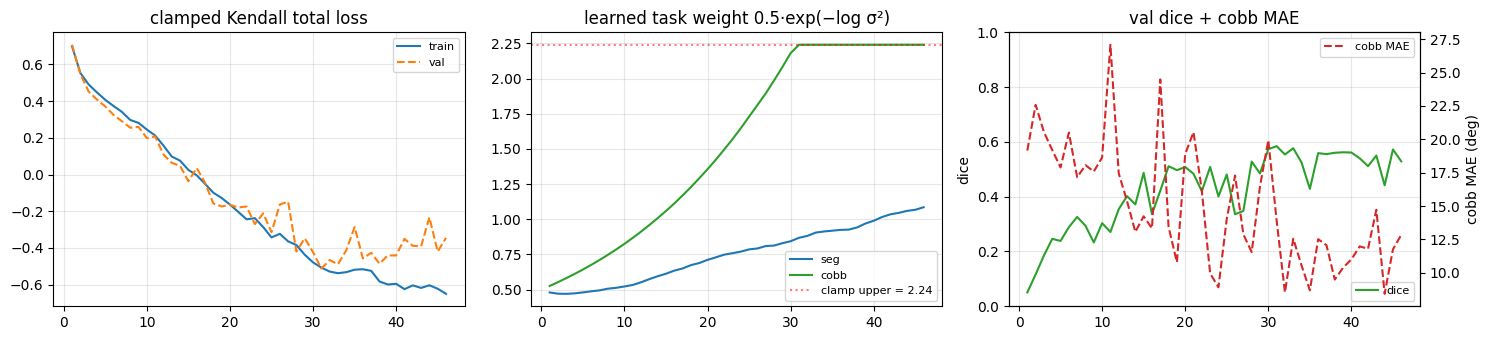

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
ax = axes[0]
ax.plot(history_df["epoch"], history_df["train_loss"], label="train")
ax.plot(history_df["epoch"], history_df["val_loss"], label="val", linestyle="--")
ax.set_title("clamped Kendall total loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(history_df["epoch"], history_df["w_seg"], label="seg", color="tab:blue")
ax.plot(history_df["epoch"], history_df["w_cobb"], label="cobb", color="tab:green")
ax.axhline(0.5*np.exp(1.5), linestyle=":", color="red", alpha=0.5, label=f"clamp upper = {0.5*np.exp(1.5):.2f}")
ax.set_title("learned task weight 0.5·exp(−log σ²)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[2]
ax.plot(history_df["epoch"], history_df["val_dice"], color="tab:green", label="dice")
ax.set_ylim(0, 1); ax.set_ylabel("dice")
ax2 = ax.twinx()
ax2.plot(history_df["epoch"], history_df["val_cobb_mae"], color="tab:red", linestyle="--", label="cobb MAE")
ax2.set_ylabel("cobb MAE (deg)")
ax.set_title("val dice + cobb MAE"); ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 7 · Evaluation

Three Cobb estimators (kpt path retired):
1. **cobb_direct** — `cobb_head` scalar
2. **cobb_from_seg** — argmax of `seg_head` → `cobb_from_segmentation_tangent`
3. **inverse-MAE-weighted ensemble** of 1 + 2

Severity is derived by bucketing each Cobb estimate.

In [14]:
@torch.no_grad()
def evaluate_case(model, row):
    case = preprocess_case(row)
    out = model(case["image"].unsqueeze(0).to(DEVICE))
    sp = out["seg"].argmax(dim=1).squeeze(0).cpu()
    cd = float(out["cobb"].squeeze(0).cpu())
    ds = []
    for c in range(1, NUM_SEG_CLASSES):
        p, g = (sp == c), (case["seg"] == c)
        d = p.sum() + g.sum()
        if d > 0: ds.append(float(2.0 * (p & g).sum() / d))
    cs = float(cobb_from_segmentation_tangent(sp.numpy()))
    out_row = {
        "dice": float(np.mean(ds)) if ds else np.nan,
        "cobb_direct": cd, "cobb_from_seg": cs,
    }
    gt = row.get("cobb_angle_deg")
    if pd.notna(gt):
        gt = float(gt)
        out_row["cobb_true"] = gt
        out_row["sev_true"] = severity_name(gt)
        for k in ("cobb_direct", "cobb_from_seg"):
            v = out_row[k]
            out_row[f"{k}_abs_err"] = abs(v - gt) if np.isfinite(v) else np.nan
            out_row[f"{k}_sev"] = severity_name(v) if np.isfinite(v) else "unknown"
    return out_row

eval_df = pd.DataFrame([evaluate_case(model, r) for _, r in VAL_DF.iterrows()])
print(f"evaluated {len(eval_df)} val cases")
eval_df.head()

evaluated 50 val cases


,dice,cobb_direct,cobb_from_seg,cobb_true,sev_true,cobb_direct_abs_err,cobb_direct_sev,cobb_from_seg_abs_err,cobb_from_seg_sev
0,0.333080,67.063194,68.963490,80.171357,severe,13.108163,severe,11.207868,severe
1,0.893114,32.098125,11.259717,NaN,NaN,NaN,NaN,NaN,NaN
2,0.337088,69.197197,140.485348,90.000000,severe,20.802803,severe,50.485348,severe
3,0.775170,37.284153,14.661334,NaN,NaN,NaN,NaN,NaN,NaN
4,0.787192,37.261681,41.554182,37.935438,moderate,0.673757,moderate,3.618744,severe


In [15]:
summary = {"n_val": int(len(eval_df)), "mean_dice": float(eval_df["dice"].mean())}
with_gt = eval_df.dropna(subset=["cobb_true"]) if "cobb_true" in eval_df else pd.DataFrame()
if len(with_gt):
    summary["n_with_cobb_gt"] = int(len(with_gt))
    for col in ("cobb_direct", "cobb_from_seg"):
        e = with_gt[f"{col}_abs_err"].dropna()
        if len(e):
            summary[f"{col}_mae"] = float(e.mean())
            summary[f"{col}_median"] = float(e.median())
            summary[f"{col}_r"] = float(with_gt[[col, "cobb_true"]].corr().iloc[0, 1])
            summary[f"{col}_sev_acc"] = float((with_gt[f"{col}_sev"] == with_gt["sev_true"]).mean())
    mae_d = with_gt["cobb_direct_abs_err"].mean()
    mae_s = with_gt["cobb_from_seg_abs_err"].mean()
    w_d, w_s = 1/mae_d, 1/mae_s
    cobb_ens = (with_gt["cobb_direct"] * w_d + with_gt["cobb_from_seg"] * w_s) / (w_d + w_s)
    summary["cobb_ensemble_mae"] = float((cobb_ens - with_gt["cobb_true"]).abs().mean())

print("=== Multi-Task v3 — seg + cobb_direct ===")
for k, v in summary.items():
    print(f"  {k:30s} {v:.3f}" if isinstance(v, float) else f"  {k:30s} {v}")
print("\n=== Reference ===")
print("  v1 (4-head naive Kendall absent):")
print("    mean_dice=0.684  cobb_direct MAE=9.34° (r=0.838, sev_acc=0.844)")
print("    cobb_from_seg MAE=13.44° · ensemble (3-way) MAE=8.25°")
print("  v2 (4-head + Kendall blowup):")
print("    mean_dice=0.528  cobb_direct MAE=12.65° (r=0.659, sev_acc=0.812)")
print("    cobb_from_seg MAE=10.39° · ensemble MAE=10.89°")

=== Multi-Task v3 — seg + cobb_direct ===
  n_val                          50
  mean_dice                      0.561
  n_with_cobb_gt                 32
  cobb_direct_mae                13.926
  cobb_direct_median             14.132
  cobb_direct_r                  0.873
  cobb_direct_sev_acc            0.750
  cobb_from_seg_mae              14.782
  cobb_from_seg_median           10.407
  cobb_from_seg_r                0.752
  cobb_from_seg_sev_acc          0.812
  cobb_ensemble_mae              8.843

=== Reference ===
  v1 (4-head naive Kendall absent):
    mean_dice=0.684  cobb_direct MAE=9.34° (r=0.838, sev_acc=0.844)
    cobb_from_seg MAE=13.44° · ensemble (3-way) MAE=8.25°
  v2 (4-head + Kendall blowup):
    mean_dice=0.528  cobb_direct MAE=12.65° (r=0.659, sev_acc=0.812)
    cobb_from_seg MAE=10.39° · ensemble MAE=10.89°


## 8 · Conclusions

Fill in after first run.

- **Did dropping kpt + sev recover dice?** Target ≥ 0.684 (v1).
- **Did the clamped Kendall stay sane?** Plot 2 should show `w_seg` and `w_cobb` both bounded (max 2.24).
- **Did `cobb_direct` regain v1 stability?** Target MAE ≤ 9.34°, r ≥ 0.838.
- **Severity-from-cobb_direct accuracy** vs v1 baseline 0.844.
- **Ensemble** (cobb_direct + cobb_from_seg, 2-way inv-MAE-weighted) vs v1's 3-way 8.25°.
- **If v3 wins:** promote to `notebooks/experiments/multitask_segcobb/` with Conclusions cell, then `notebooks/final/`, then `ai/models/architectures/seg_cobb_encoder_unet.py`.